In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install "chronos-forecasting>=2.0.0" accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
!pip install autogluon.timeseries autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter co

In [3]:
import autogluon.timeseries
print(autogluon.timeseries.__version__)

1.5.0


# **Load data**

In [4]:
import pandas as pd
from datasets import load_dataset
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# 2. Tải dữ liệu từ Hugging Face (volta-solar-daily-v1)
ds = load_dataset("codenhenhe/volta-solar-daily-v1")
train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df   = ds["test"].to_pandas()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/11.2M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/23.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1278500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/182500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/365500 [00:00<?, ? examples/s]

In [5]:
ds

DatasetDict({
    train: Dataset({
        features: ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M', 'T_cell', 'temp_factor', 'solar_gen_kwh', 'day_of_year', 'month', '__index_level_0__'],
        num_rows: 1278500
    })
    validation: Dataset({
        features: ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M', 'T_cell', 'temp_factor', 'solar_gen_kwh', 'day_of_year', 'month', '__index_level_0__'],
        num_rows: 182500
    })
    test: Dataset({
        features: ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M', 'T_cell', 'temp_factor', 'solar_gen_kwh', 'day_of_year', 'month', '__index_level_0__'],
        num_rows: 365500
    })
})

In [6]:
val_df

,solar_ref_id,date,lat,long,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,T_cell,temp_factor,solar_gen_kwh,day_of_year,month,__index_level_0__
0,AUS_SOLAR_REF_000,2023-01-01,-27.832,114.852,9.1733,25.61,5.55,45.88,48.54325,0.917599,44.443911,1,1,2557
1,AUS_SOLAR_REF_000,2023-01-02,-27.832,114.852,8.5126,32.21,6.23,25.99,53.49150,0.900280,40.464449,2,1,2558
2,AUS_SOLAR_REF_000,2023-01-03,-27.832,114.852,8.4670,34.70,6.61,17.99,55.86750,0.891964,39.875917,3,1,2559
3,AUS_SOLAR_REF_000,2023-01-04,-27.832,114.852,8.3974,35.58,5.41,15.56,56.57350,0.889493,39.438571,4,1,2560
4,AUS_SOLAR_REF_000,2023-01-05,-27.832,114.852,8.5397,35.16,4.59,17.12,56.50925,0.889718,40.117026,5,1,2561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182495,AUS_SOLAR_REF_499,2023-12-27,-33.865,147.461,7.2103,20.54,1.51,65.12,38.56575,0.952520,36.262797,361,12,1825764
182496,AUS_SOLAR_REF_499,2023-12-28,-33.865,147.461,8.2466,24.75,3.24,53.63,45.36650,0.928717,40.438251,362,12,1825765
182497,AUS_SOLAR_REF_499,2023-12-29,-33.865,147.461,3.1534,22.16,2.31,63.87,30.04350,0.982348,16.356043,363,12,1825766
182498,AUS_SOLAR_REF_499,2023-12-30,-33.865,147.461,9.3598,21.01,3.01,53.42,44.40950,0.932067,46.062500,364,12,1825767


In [7]:
def prepare_data(df):
    # Đổi tên các cột bắt buộc của AutoGluon
    # item_id: ID của trạm (solar_ref_id)
    # timestamp: Thời gian (date)
    # target: Giá trị cần dự báo (solar_gen_kwh)
    df = df.rename(columns={
        "solar_ref_id": "item_id",
        "date": "timestamp",
        "solar_gen_kwh": "target"
    })

    # Chuyển timestamp sang định dạng datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Loại bỏ cột index thừa nếu có để tránh nhiễu
    if "__index_level_0__" in df.columns:
        df = df.drop(columns=["__index_level_0__", "lat", "long"])

    # Tạo TimeSeriesDataFrame
    # AutoGluon sẽ tự hiểu các cột còn lại (T2M, WS2M, RH2M,...) là covariates
    return TimeSeriesDataFrame(df)

train_data_raw = prepare_data(train_df)
val_data_raw = prepare_data(val_df)

tuning_data = pd.concat([train_data_raw, val_data_raw]).sort_values(["item_id", "timestamp"])
tuning_data = TimeSeriesDataFrame(tuning_data)

In [8]:
train_data_raw

ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M    T_cell  \
item_id           timestamp                                                     
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78  53.53600   
                  2016-01-02             8.5466  26.56  4.61  53.99  47.92650   
                  2016-01-03             8.2236  26.15  2.78  55.57  46.70900   
                  2016-01-04             5.6350  25.23  3.16  58.72  39.31750   
                  2016-01-05             5.3940  24.70  3.66  59.91  38.18500   
...                                         ...    ...   ...    ...       ...   
AUS_SOLAR_REF_499 2022-12-27             9.3326  26.98  2.85  41.82  50.31150   
                  2022-12-28             9.2441  26.85  3.63  45.91  49.96025   
                  2022-12-29             2.9136  24.17  1.60  66.30  31.45400   
                  2022-12-30             8.2678  23.28  1.97  69.98  43.94950   
                  2022-12-31             7.7484  24.00  2.23  61.61  43.37100   

                              temp_factor     target  day_of_year  month  
item_id           timestamp                                               
AUS_SOLAR_REF_000 2016-01-01     0.900124  42.557171            1      1  
                  2016-01-02     0.919757  41.505010            2      1  
                  2016-01-03     0.924018  40.121445            3      1  
                  2016-01-04     0.949889  28.261850            4      1  
                  2016-01-05     0.953852  27.166024            5      1  
...                                   ...        ...          ...    ...  
AUS_SOLAR_REF_499 2022-12-27     0.911410  44.910744          361     12  
                  2022-12-28     0.912639  44.544864          362     12  
                  2022-12-29     0.977411  15.036303          363     12  
                  2022-12-30     0.933677  40.758710          364     12  
                  2022-12-31     0.935701  38.281001          365     12  

[1278500 rows x 9 columns]

In [9]:
tuning_data

ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M    T_cell  \
item_id           timestamp                                                     
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78  53.53600   
                  2016-01-02             8.5466  26.56  4.61  53.99  47.92650   
                  2016-01-03             8.2236  26.15  2.78  55.57  46.70900   
                  2016-01-04             5.6350  25.23  3.16  58.72  39.31750   
                  2016-01-05             5.3940  24.70  3.66  59.91  38.18500   
...                                         ...    ...   ...    ...       ...   
AUS_SOLAR_REF_499 2023-12-27             7.2103  20.54  1.51  65.12  38.56575   
                  2023-12-28             8.2466  24.75  3.24  53.63  45.36650   
                  2023-12-29             3.1534  22.16  2.31  63.87  30.04350   
                  2023-12-30             9.3598  21.01  3.01  53.42  44.40950   
                  2023-12-31             8.7427  22.94  1.98  52.82  44.79675   

                              temp_factor     target  day_of_year  month  
item_id           timestamp                                               
AUS_SOLAR_REF_000 2016-01-01     0.900124  42.557171            1      1  
                  2016-01-02     0.919757  41.505010            2      1  
                  2016-01-03     0.924018  40.121445            3      1  
                  2016-01-04     0.949889  28.261850            4      1  
                  2016-01-05     0.953852  27.166024            5      1  
...                                   ...        ...          ...    ...  
AUS_SOLAR_REF_499 2023-12-27     0.952520  36.262797          361     12  
                  2023-12-28     0.928717  40.438251          362     12  
                  2023-12-29     0.982348  16.356043          363     12  
                  2023-12-30     0.932067  46.062500          364     12  
                  2023-12-31     0.930711  42.962992          365     12  

[1461000 rows x 9 columns]

# Load model and finetune

In [10]:
prediction_length = 365

predictor = TimeSeriesPredictor(
    target='target',
    prediction_length=prediction_length,
    path="/content/autogluon_chronos_lora_solar",
    eval_metric="MSE",
    known_covariates_names=['day_of_year', 'month']
)

In [11]:
hyperparameters = {
    "Chronos2": [
        # 1. Bản Zero-shot (Chỉ dự báo, không học thêm)
        {"ag_args": {"name_suffix": "_ZeroShot"}},

        # 2. Bản Fine-tuned (Có học thêm với LoRA)
        {
            "fine_tune": True,
            "fine_tune_mode": "lora",
            "fine_tune_lr": 1e-4,
            "fine_tune_batch_size": 8,
            "ag_args": {"name_suffix": "_FineTuned"}
        },
    ]
}

In [12]:
predictor.fit(
    train_data=train_data_raw,
    tuning_data=tuning_data,
    hyperparameters=hyperparameters,
    time_limit=3600,
    enable_ensemble=False,
)

Beginning AutoGluon training... Time limit = 3600s
AutoGluon will save models to '/content/autogluon_chronos_lora_solar'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.72 GB / 12.67 GB (84.6%)
Disk Space Avail:   64.57 GB / 112.64 GB (57.3%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MSE,
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': '_ZeroShot'}},
                                  {'ag_args': {'name_suffix': '_FineTuned'},
                                   'fine_tune': True,
                                   'fine_tune_batch_size': 8,
         

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

	-35.7612      = Validation score (-MSE)
	19.55   s     = Training runtime
	81.70   s     = Validation (prediction) runtime
Training timeseries model Chronos2_FineTuned. Training for up to 3491.4s of the 3491.4s of remaining time.
	-35.4985      = Validation score (-MSE)
	277.78  s     = Training runtime
	107.32  s     = Validation (prediction) runtime
Training complete. Models trained: ['Chronos2_ZeroShot', 'Chronos2_FineTuned']
Total runtime: 487.26 s
Best model: Chronos2_FineTuned
Best model score: -35.4985


In [14]:
test_data_raw = prepare_data(test_df)

test_data_combined = pd.concat([train_data_raw, val_data_raw, test_data_raw])
test_data_combined = TimeSeriesDataFrame(test_data_combined).sort_values(["item_id", "timestamp"])

test_data_combined

ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M    T_cell  \
item_id           timestamp                                                     
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78  53.53600   
                  2016-01-02             8.5466  26.56  4.61  53.99  47.92650   
                  2016-01-03             8.2236  26.15  2.78  55.57  46.70900   
                  2016-01-04             5.6350  25.23  3.16  58.72  39.31750   
                  2016-01-05             5.3940  24.70  3.66  59.91  38.18500   
...                                         ...    ...   ...    ...       ...   
AUS_SOLAR_REF_499 2025-12-27             9.6631  19.30  2.33  41.20  43.45775   
                  2025-12-28             8.7079  21.64  3.20  37.60  43.40975   
                  2025-12-29             9.6110  24.35  1.99  34.56  48.37750   
                  2025-12-30             8.8459  27.43  1.90  27.50  49.54475   
                  2025-12-31             8.4458  28.13  3.41  25.73  49.24450   

                              temp_factor     target  day_of_year  month  
item_id           timestamp                                               
AUS_SOLAR_REF_000 2016-01-01     0.900124  42.557171            1      1  
                  2016-01-02     0.919757  41.505010            2      1  
                  2016-01-03     0.924018  40.121445            3      1  
                  2016-01-04     0.949889  28.261850            4      1  
                  2016-01-05     0.953852  27.166024            5      1  
...                                   ...        ...          ...    ...  
AUS_SOLAR_REF_499 2025-12-27     0.935398  47.725092          361     12  
                  2025-12-28     0.935566  43.015178          362     12  
                  2025-12-29     0.918179  46.593972          363     12  
                  2025-12-30     0.914093  42.693967          364     12  
                  2025-12-31     0.915144  40.809782          365     12  

[1826500 rows x 9 columns]

In [16]:
leaderboard = predictor.leaderboard(test_data_combined)
print(leaderboard)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


                model  score_test  score_val  pred_time_test  pred_time_val  \
0  Chronos2_FineTuned  -35.334949 -35.498534      120.993108     107.316278   
1   Chronos2_ZeroShot  -36.192532 -35.761151      120.462285      81.702909   

   fit_time_marginal  fit_order  
0         277.779197          2  
1          19.545354          1  


In [20]:
forecast_start_date = '2025-01-01'

past_data = test_data_combined.query(f"timestamp < '{forecast_start_date}'")

future_known_data = test_data_combined.query(f"timestamp >= '{forecast_start_date}'")

print(past_data)
print(future_known_data)

                              ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M   T_cell  \
item_id           timestamp                                                    
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78  53.5360   
                  2016-01-02             8.5466  26.56  4.61  53.99  47.9265   
                  2016-01-03             8.2236  26.15  2.78  55.57  46.7090   
                  2016-01-04             5.6350  25.23  3.16  58.72  39.3175   
                  2016-01-05             5.3940  24.70  3.66  59.91  38.1850   
...                                         ...    ...   ...    ...      ...   
AUS_SOLAR_REF_499 2024-12-27             9.0422  23.97  4.07  39.92  46.5755   
                  2024-12-28             8.9806  20.70  2.78  38.84  43.1515   
                  2024-12-29             9.2892  22.96  2.24  45.36  46.1830   
                  2024-12-30             8.7276  25.67  1.64  40.74  47.4890   
                  2024-12-31            

In [24]:
known_covariates = future_known_data[['day_of_year', 'month']]

predictions = predictor.predict(
    past_data,
    known_covariates=known_covariates,
    model="Chronos2_FineTuned"
)

print(predictions.head())

                                   mean        0.1        0.2        0.3  \
item_id           timestamp                                                
AUS_SOLAR_REF_000 2025-01-01  39.978298  33.464108  36.190018  37.804893   
                  2025-01-02  41.742168  34.357933  37.527931  39.460541   
                  2025-01-03  42.064056  34.909470  38.232544  39.965355   
                  2025-01-04  42.387302  35.361301  38.622402  40.275066   
                  2025-01-05  42.455597  35.405804  38.758926  40.507011   

                                    0.4        0.5        0.6        0.7  \
item_id           timestamp                                                
AUS_SOLAR_REF_000 2025-01-01  38.987411  39.978298  40.807003  41.538658   
                  2025-01-02  40.779713  41.742168  42.475056  43.127563   
                  2025-01-03  41.134613  42.064056  42.756531  43.410404   
                  2025-01-04  41.481148  42.387302  43.180294  43.753479   
           

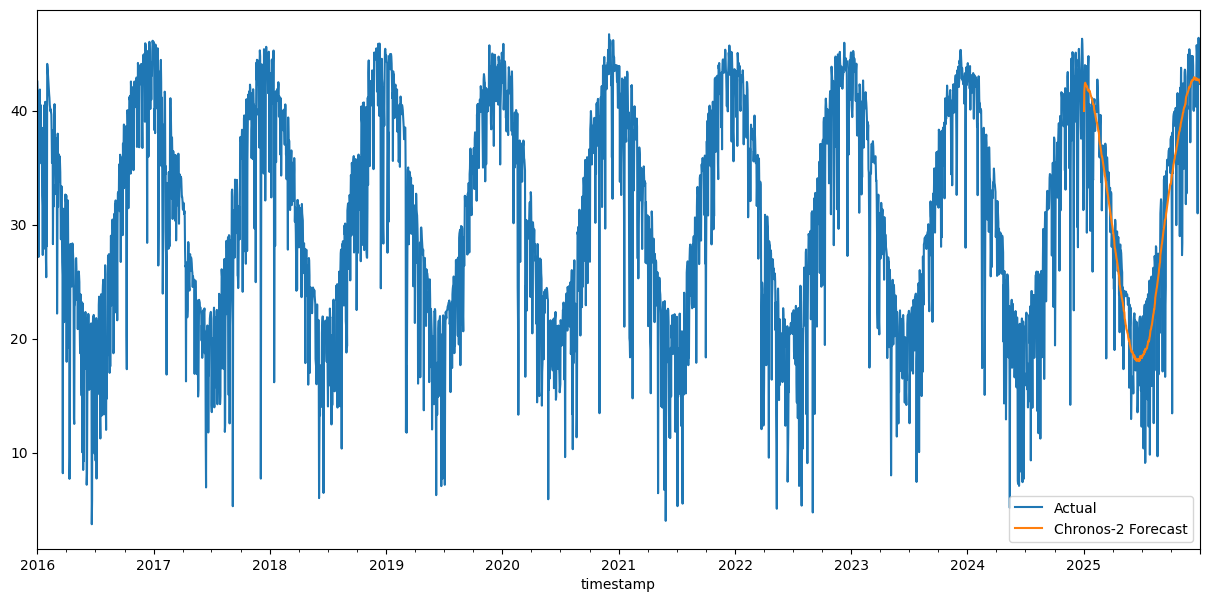

In [25]:
# Chọn một trạm (item_id) bất kỳ để xem thử
import matplotlib.pyplot as plt
target_item = "AUS_SOLAR_REF_000"

plt.figure(figsize=(15, 7))
# Vẽ dữ liệu thực tế
test_data_combined.loc[target_item]['target'].plot(label="Actual")
# Vẽ dự báo
predictions.loc[target_item]['0.5'].plot(label="Chronos-2 Forecast")
plt.legend()
plt.show()